<a href="https://colab.research.google.com/github/chrisandrachristopher12-max/IMDB-Movie-Rating-Predictions-Group-10/blob/main/Milestone_1_Data_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving IMDB_Movie_Dataset.csv to IMDB_Movie_Dataset.csv
=== DATASET PREVIEW ===
  Released_Year Certificate  Runtime                 Genre  IMDB_Rating  \
0          1994           A  142 min                 Drama          9.3   
1          1972           A  175 min          Crime, Drama          9.2   
2          2008          UA  152 min  Action, Crime, Drama          9.0   
3          1974           A  202 min          Crime, Drama          9.0   
4          1957           U   96 min          Crime, Drama          9.0   

   Meta_score  No_of_Votes        Gross  
0        80.0      2343110   28341469.0  
1       100.0      1620367  134966411.0  
2        84.0      2303232  534858444.0  
3        90.0      1129952   57300000.0  
4        96.0       689845    4360000.0  

Shape: (1000, 8)

=== DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         -----------

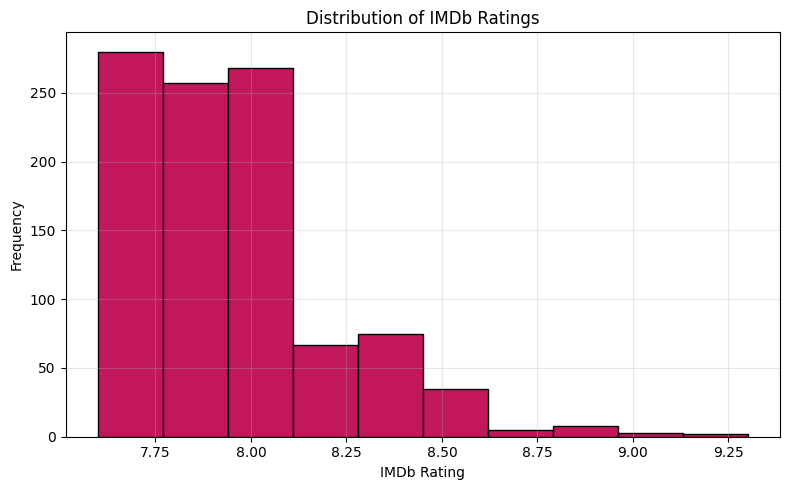


Categorical data encoded successfully.


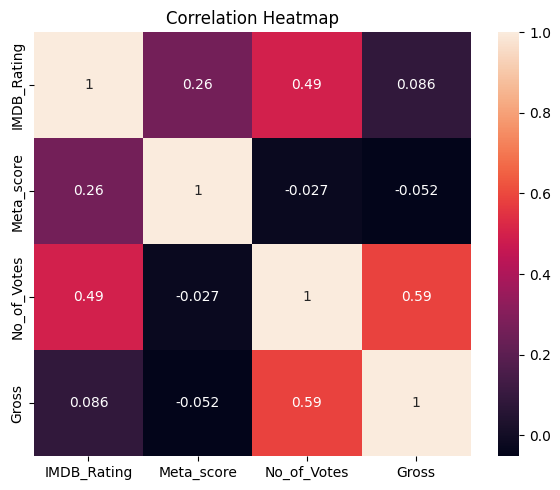


Preprocessed dataset saved as IMDB_Movie_Dataset_Preprocessed.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Milestone 1 Completed!
Dataset is clean and ready for machine learning.


In [2]:
# MILESTONE 1: DATA PIPELINE (Google Colab Version)

# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# =========================
# UPLOAD DATASET IN COLAB
# =========================
from google.colab import files
uploaded = files.upload()   # Select IMDB_Movie_Dataset.csv

# =========================
# LOAD DATASET
# =========================
df = pd.read_csv("IMDB_Movie_Dataset.csv")

print("=== DATASET PREVIEW ===")
print(df.head())

print("\nShape:", df.shape)

# =========================
# EXPLORATORY DATA ANALYSIS
# =========================
print("\n=== DATA INFO ===")
print(df.info())

print("\n=== CHECK MISSING VALUES ===")
print(df.isnull().sum())

# =========================
# DISTRIBUTION OF IMDb RATINGS
# =========================
if 'IMDB_Rating' in df.columns:
    plt.figure(figsize=(8, 5))
    df['IMDB_Rating'].hist(
        bins=10,
        color='#C2185B',   # Dark pink
        edgecolor='black'
    )
    plt.title("Distribution of IMDb Ratings")
    plt.xlabel("IMDb Rating")
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# =========================
# PREPROCESSING
# =========================
le = LabelEncoder()

for col in ['Genre', 'Certificate']:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))

print("\nCategorical data encoded successfully.")

# =========================
# CORRELATION HEATMAP
# =========================
cols = ['IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross']
cols = [c for c in cols if c in df.columns]

if len(cols) > 1:
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        df[cols].corr(),
        annot=True
    )
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()

# =========================
# SAVE PREPROCESSED DATA
# =========================
df.to_csv("IMDB_Movie_Dataset_Preprocessed.csv", index=False)

print("\nPreprocessed dataset saved as IMDB_Movie_Dataset_Preprocessed.csv")

# =========================
# DOWNLOAD PREPROCESSED FILE
# =========================
files.download("IMDB_Movie_Dataset_Preprocessed.csv")

# =========================
# COMPLETION MESSAGE
# =========================
print("\nMilestone 1 Completed!")
print("Dataset is clean and ready for machine learning.")
